# 03 -- Spatial (S): Tối ưu Stage 3 (Where)

Notebook này chỉ tập trung cải thiện điểm **S** (spatial Gaussian similarity, vị trí điểm va chạm). `core` đã cung cấp baseline `stage3_grounding` hiện tại (1 lời gọi VLM, hỏi điểm va chạm dạng point trên 1 frame tại `t_final`).

**Chưa có lịch sử thử nghiệm riêng cho S** trong notebook gốc -- đây là notebook 'trắng' nhất trong 3 cái, mục 6.6 (`Stage3a -- optical-flow weighted centroid`) chỉ là baseline classical cũ (đã chuyển sang `legacy/`), còn `stage3_grounding` (VLM) chưa từng được đào sâu như T và C.

**Quy tắc khi làm việc ở đây:** chỉ định nghĩa hàm MỚI (ví dụ `stage3_grounding_v2`), không sửa `stage3_grounding` gốc trong core. So sánh S mới với `eval_core['S'].mean()`.

In [ ]:
# [SETUP] Tu dong lay core pipeline tu GitHub repo -- khong can mount repo thu cong,
# chay duoc ngay tren Kaggle/Colab (session moi, chua co gi tren may) LAN local co
# san repo (khong clone lai, tu tim thu muc goc).
import os, sys, subprocess

REPO_URL  = 'https://github.com/HoangDinhBui/zero-shot-cctv-accident.git'
REPO_NAME = 'zero-shot-cctv-accident'

def _find_or_clone_repo_root():
    cwd = os.getcwd()
    # Da dang chay tu trong repo (notebook nay o notebooks/, core/ o thu muc cha)
    for base in (cwd, os.path.dirname(cwd)):
        if os.path.exists(os.path.join(base, 'core', 'shared_pipeline.ipynb')):
            return os.path.abspath(base)
    # Chua co -- clone ve thu muc hien tai (Kaggle/Colab session moi)
    if not os.path.exists(REPO_NAME):
        print(f'[SETUP] Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', '--depth', '1', '-q', REPO_URL], check=True)
    return os.path.abspath(REPO_NAME)

REPO_ROOT = _find_or_clone_repo_root()
sys.path.append(os.path.join(REPO_ROOT, 'core'))
print(f'[SETUP] REPO_ROOT = {REPO_ROOT}')

CORE_NB_PATH = os.path.join(REPO_ROOT, 'core', 'shared_pipeline.ipynb')
print(f'[SETUP] Loading core pipeline: {CORE_NB_PATH}')

In [ ]:
# Nap toan bo core (data, model loading, 3-stage baseline, eval, diverse_videos).
# Cac cell pip-install / fix NVRTC / load Qwen3-VL da nam san trong core, se tu
# chay khi %run toi do -- khong can them cell cai thu vien rieng o day.
%run {CORE_NB_PATH}

## Điểm khởi đầu -- breakdown S hiện tại

Cell dưới đây (điều chỉnh từ Section 7 gốc, `eval_final` -> `eval_core` cho khớp core mới) vẽ phân bố lỗi khoảng cách + độ nhạy của Gaussian scoring quanh giá trị SIGMA_X/SIGMA_Y đã fit ở core -- hữu ích để biết ngay bây giờ lỗi S đến từ đâu (lệch hệ thống theo 1 trục, hay nhiễu ngẫu nhiên) trước khi thử sửa.

In [ ]:
# [EVAL] Component score distributions vs. the constant floor -- baseline hien tai (core)
if not eval_core.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    score_cols  = ['T', 'S', 'C']
    score_names = ['Temporal Score', 'Spatial Score', 'Classification Score']
    colors      = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary']]

    for ax, col, name, color in zip(axes, score_cols, score_names, colors):
        sns.histplot(eval_core[col], bins=20, kde=True, color=color, ax=ax)
        ax.axvline(eval_core[col].mean(), linestyle='--', color='black',
                   linewidth=1.2, label=f'pipeline={eval_core[col].mean():.3f}')
        ax.axvline(const_eval[col].mean(), linestyle=':', color='crimson',
                   linewidth=1.6, label=f'constant={const_eval[col].mean():.3f}')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Score', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.legend(fontsize=9)

    plt.suptitle(f'Component Scores vs. Constant Floor -- core baseline '
                 f'({accident_score(eval_core):.4f} vs floor {accident_score(const_eval):.4f})',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

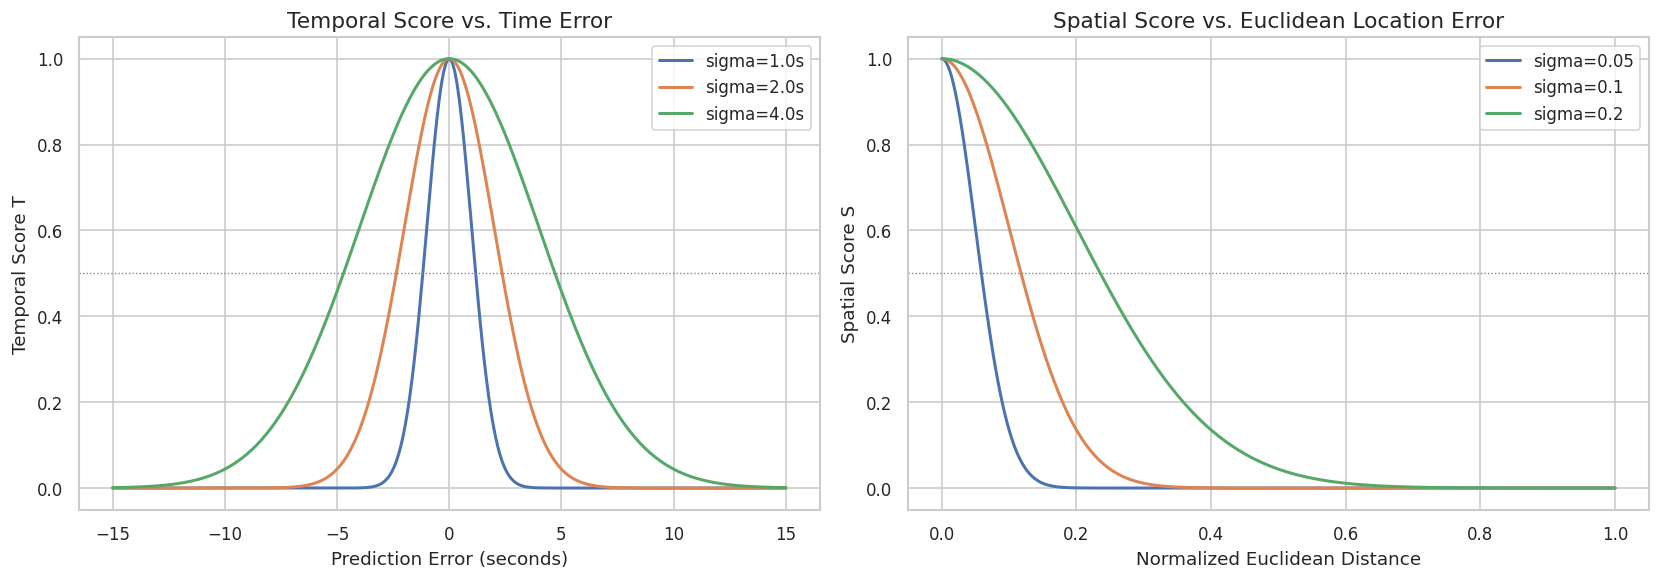

In [64]:
# [EVAL] Score sensitivity analysis -- Gaussian scoring curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_errors = np.linspace(-15, 15, 300)  # seconds from ground truth
for sigma in [1.0, 2.0, 4.0]:
    axes[0].plot(time_errors, np.exp(-0.5 * (time_errors / sigma) ** 2),
                 label=f'sigma={sigma}s', linewidth=1.8)
axes[0].set_title('Temporal Score vs. Time Error')
axes[0].set_xlabel('Prediction Error (seconds)')
axes[0].set_ylabel('Temporal Score T')
axes[0].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)
axes[0].legend()

dist_errors = np.linspace(0, 1.0, 300)  # normalized Euclidean distance
for sigma in [0.05, 0.10, 0.20]:
    axes[1].plot(dist_errors, np.exp(-0.5 * (dist_errors / sigma) ** 2),
                 label=f'sigma={sigma}', linewidth=1.8)
axes[1].set_title('Spatial Score vs. Euclidean Location Error')
axes[1].set_xlabel('Normalized Euclidean Distance')
axes[1].set_ylabel('Spatial Score S')
axes[1].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

## Hướng gợi ý để bắt đầu (chưa thử)

Dựa trên đúng bài học đã rút ra ở `02_type_C` (VLM bị collapse khi phải chọn từ tập giá trị neo rời rạc, kể cả khi neo là số): `stage3_grounding` hiện tại hỏi thẳng `center_x, center_y` -- rủi ro tương tự có thể xảy ra (model đoán về (0.5, 0.5) hoặc vài toạ độ neo quen thuộc bất kể nội dung). Thí nghiệm content-free đầu tiên nên làm ở đây: đo `stage3_grounding` trên khung hình PRE-COLLISION thật -- nếu toạ độ trả về vẫn hội tụ mạnh về 1-2 điểm cố định ngay cả khi chưa có va chạm, đó là cùng một loại bias đã thấy ở C, không phải lỗi grounding thật.

---
# 🔧 KHU VỰC DEV — Spatial (S)
### Người phụ trách S viết code TỪ ĐÂY XUỐNG DƯỚI. Không sửa gì ở trên (đó là core + baseline breakdown).
---

**Việc cần làm:** định nghĩa hàm grounding MỚI (ví dụ `stage3_grounding_vNEXT`), KHÔNG sửa `stage3_grounding` gốc import từ `core`. Gợi ý thí nghiệm đầu tiên: đo content-free bias giống hệt cách đã làm ở `02_type_C` (hỏi grounding trên khung hình CHƯA va chạm, xem toạ độ có hội tụ về vài điểm cố định không).

In [ ]:
# TODO: dinh nghia ham grounding vi tri va cham moi cho S o day.
# Vi du khung san (xoa va viet lai theo huong ban chon):
#
# def stage3_grounding_vNEXT(video_path, t_final):
#     ...
#     return (center_x, center_y)   # normalized 0-1, hoac None neu khong xac dinh duoc


In [ ]:
# [EVAL] So sanh S moi vs baseline core -- CHAY CELL NAY TRUOC KHI MO PR.
# Doi ten ham trong vong lap ben duoi thanh ham ban vua dinh nghia o tren.

rows_S_new = []
for vp, gt_type in zip(diverse_videos, diverse_labels_df['type']):
    sub_path = 'videos/' + vp.name
    scene = SCENE_BY_PATH.get(sub_path)
    cap = cv2.VideoCapture(str(vp))
    fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (n / fps) if fps > 0 else 20.0

    pred = stage1_full_scan(vp, duration, scene)                              # giu nguyen (core)
    t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration) # giu nguyen (core)

    # <-- doi dong duoi day sang ham moi cua ban -->
    pt = stage3_grounding(vp, t_final)
    if pt is not None:
        pred['center_x'], pred['center_y'] = pt

    pred['type'] = classify_type_cascade(vp, t_final, pred['type'])          # giu nguyen (core)
    pred['type'] = apply_scene_type_postfix(pred['type'], scene)             # giu nguyen (core)

    rows_S_new.append({'path': str(vp), 'accident_time': t_final,
                       'center_x': pred['center_x'], 'center_y': pred['center_y'],
                       'type': pred['type']})

eval_S_new = score_predictions(pd.DataFrame(rows_S_new), diverse_labels_df)
print(f"[BASELINE] S = {eval_core['S'].mean():.4f}")
print(f"[MOI]      S = {eval_S_new['S'].mean():.4f}")
print(f"[DELTA]        {eval_S_new['S'].mean() - eval_core['S'].mean():+.4f}")